# Examen Data Scientist - Data analyseren in Python

## Introductie
Voor dit examen is het belangrijk dat je volgende zaken zeker doet:
 - Zorg dat je op het einde de tijd neemt om je code op te schonen zodat deze begrijpelijk is voor derden.
 - Wanneer je klaar bent, upload het notebook in de leeromgeving

In deze opgave bekijken we een gesimuleerde dataset over de geboortes in België van 2019. De data is in de map `Data\raw_data` te vinden in `.csv` bestanden die gelabeld zijn met de echte geboortedag van de personen in het bestand. Laat ons bijvoorbeeld even kijken naar de eerste 5 lijnen van het bestand `2019-1-1.csv`:

<table align="center">
  <tr>
    <th>gemeente</th>
    <th>naam</th>
    <th>geslacht</th>
    <th>verwachte datum</th>
  </tr>
  <tr>
    <td>Hooglede</td>
    <td>Elias</td>
    <td>Mannelijk</td>
    <td>01/14/2019</td>
  </tr>
  <tr>
    <td>Sint-Niklaas (Sint-Niklaas)</td>
    <td>Pauline</td>
    <td>Vrouwelijk</td>
    <td>01/05/2019</td>
  </tr>
  <tr>
    <td>Wijnegem</td>
    <td>Anita</td>
    <td>Vrouwelijk</td>
    <td>01/05/2019</td>
  </tr>
  <tr>
    <td>Grâce-Hollogne</td>
    <td>Jean-Paul</td>
    <td>Mannelijk</td>
    <td>01/13/2019</td>
  </tr>
  <tr>
    <td>Boussu</td>
    <td>François</td>
    <td>Mannelijk</td>
    <td>01/26/2019</td>
  </tr>
</table>


Hier hebben we de kolommen:
 - **gemeente**: De gemeente waar de persoon geboren is.
 - **naam**: De voornaam van de persoon.
 - **geslacht**: Het geslacht van de persoon (Mannelijk of Vrouwelijk).
 - **verwachte datum**: De verwachte geboortedatum van de persoon.

Dus hier hebben we dan bijvoorbeeld op de eerste lijn de mannelijke persoon Elias die geboren is in Hooglede waarvan men verwachtte dat hij zou geboren worden op `01/14/2019` (Amerikaans formaat) maar in feite geboren is op 1 januari 2019.


# Stap 0
Met deze code kun je de data downloaden. Je kunt natuurlijk de gegevens ook zelf downloaden en uitpakken.

In [ ]:
from pathlib import Path
from zipfile import ZipFile
import requests
URL='https://github.com/Jef-DS/matplotlib/raw/refs/heads/main/Data.zip'
DATA_ZIP = 'data.zip'
data_path = Path(DATA_ZIP)
if not data_path.exists():
    data = requests.get(URL)
    with open(DATA_ZIP, 'wb') as f:
        f.write(data.content)
    with ZipFile(DATA_ZIP) as zpf:
        zpf.extractall()

## Stap 1: data inlezen(1 punt)

Maak een lus over alle bestanden in de map `Data/Raw_Data`, lees elk `.csv` bestand in en voeg deze samen tot 1 grote DataFrame. Merk op dat de datum verwerkt zit in de filename, voeg deze toe aan de kleine DataFrames voor je de dataframes samenvoegt met een `pd.concat(dfs)`.

Voeg een extra kolom toe met een `"dag van het jaar"` getal, dus 1 januari 2019 is `1`, 2 januari 2019 is `2`, enzovoort.

**Opmerking**: Er is ook data voor 29 februari 2019, terwijl dit geen schrikkeljaar is! Plaats geboortes van 29 februari 2019 in een afzonderlijke DataFrame `df_wrong`. Zet in `df_wrong` een extra kolom ('reden') met een referentie naar waarom deze data foutief is.('29-02-2019')

In [1]:
import os
import pandas as pd

df_orig = pd.DataFrame()
map = 'data/Raw_Data'

for filename in os.listdir(map):
    filepath = os.path.join(map, filename)
    if os.path.isfile(filepath):
        df_next = pd.read_csv(filepath, delimiter=',', parse_dates=['verwachte datum'], date_format='%m/%d/%Y')
        df_next['datum'] = filename[:-4] # bestandsnaam zonder extentie .csv als datum-kolom
        df_orig = pd.concat([df_orig, df_next], axis='index')

# display(df_orig.head())

# ik onthoud aantal records om later te verifieren dat niets gaat verloren
tot_records = df_orig.shape[0]
tot_records

116923

In [2]:
# maak van de rijen met een foutieve geboortedatum een aparte df

df_wrong = df_orig.loc[df_orig.datum == '2019-2-29'].rename(columns={'datum': 'reden'})

Toon de eerste 5 records van *df_wrong* (geen punten, gewoon voor jezelf om te controleren of je de juiste data hebt)

In [3]:
df_wrong.head()


,gemeente,naam,geslacht,verwachte datum,reden
0,Kruisem,Patrick,Mannelijk,2019-02-27,2019-2-29
1,Montigny-le-Tilleul,Sarah,Vrouwelijk,2019-03-11,2019-2-29
2,Diepenbeek,Valentinus,Mannelijk,2019-03-02,2019-2-29
3,Sint-Jans-Molenbeek,El,Mannelijk,2019-02-27,2019-2-29
4,Overijse,Apolline,Vrouwelijk,2019-03-03,2019-2-29


,gemeente,naam,geslacht,verwachte datum,reden
0,Kruisem,Patrick,Mannelijk,02/27/2019,2019-02-29
1,Montigny-le-Tilleul,Sarah,Vrouwelijk,03/11/2019,2019-02-29
2,Diepenbeek,Valentinus,Mannelijk,03/02/2019,2019-02-29
3,Sint-Jans-Molenbeek,El,Mannelijk,02/27/2019,2019-02-29
4,Overijse,Apolline,Vrouwelijk,03/03/2019,2019-02-29


In [4]:
# verwijderen de foutieve rijen (of liever: zet de juiste apart in df)

df = df_orig[df_orig.datum != '2019-2-29']

# check aantal rijen
print(f"{df.shape[0] + df_wrong.shape[0]=} (moet gelijk zijn aan {tot_records})")

df.shape[0] + df_wrong.shape[0]=116923 (moet gelijk zijn aan 116923)


In [5]:
# datum omzetten nr daytime en dag van het jaar kolom toevoegen
df['datum'] = pd.to_datetime(df['datum'])
df['dag_van_jaar'] = df.datum.dt.dayofyear

# misschien ook best "verwachte datum" nr zonder spacie hernoemen
df = df.rename(columns={'verwachte datum': 'verwachte_datum'})
df_wrong = df_wrong.rename(columns={'verwachte datum': 'verwachte_datum'})

df.info(), df_wrong.info()

<class 'pandas.DataFrame'>
Index: 116850 entries, 0 to 315
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   gemeente         116850 non-null  str           
 1   naam             116850 non-null  str           
 2   geslacht         116850 non-null  str           
 3   verwachte_datum  116850 non-null  datetime64[us]
 4   datum            116850 non-null  datetime64[us]
 5   dag_van_jaar     116850 non-null  int32         
dtypes: datetime64[us](2), int32(1), str(3)
memory usage: 5.8 MB
<class 'pandas.DataFrame'>
Index: 73 entries, 0 to 72
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   gemeente         73 non-null     str           
 1   naam             73 non-null     str           
 2   geslacht         73 non-null     str           
 3   verwachte_datum  73 non-null     datetime64[us]
 4   red

(None, None)

Toon de eerste 5 records van de dataset *df*

In [28]:
df.head()

,gemeente,naam,geslacht,verwachte_datum,datum,dag_van_jaar
0,Hooglede,Elias,Mannelijk,2019-01-14,2019-01-01,1
1,Sint-Niklaas (Sint-Niklaas),Pauline,Vrouwelijk,2019-01-05,2019-01-01,1
2,Wijnegem,Anita,Vrouwelijk,2019-01-05,2019-01-01,1
3,Grâce-Hollogne,Jean-Paul,Mannelijk,2019-01-13,2019-01-01,1
4,Boussu,François,Mannelijk,2019-01-26,2019-01-01,1


,gemeente,naam,geslacht,verwachte datum,date,dag van jaar
0,Hooglede,Elias,Mannelijk,2019-01-14,2019-01-01,1
1,Sint-Niklaas (Sint-Niklaas),Pauline,Vrouwelijk,2019-01-05,2019-01-01,1
2,Wijnegem,Anita,Vrouwelijk,2019-01-05,2019-01-01,1
3,Grâce-Hollogne,Jean-Paul,Mannelijk,2019-01-13,2019-01-01,1
4,Boussu,François,Mannelijk,2019-01-26,2019-01-01,1


Toon de laatste 5 records van *df*

In [29]:
df.tail()

,gemeente,naam,geslacht,verwachte_datum,datum,dag_van_jaar
311,Lede,Lobke,Vrouwelijk,2019-09-12,2019-09-09,252
312,Westerlo,Willem,Mannelijk,2019-09-04,2019-09-09,252
313,Brugge,Diane,Vrouwelijk,2019-09-20,2019-09-09,252
314,Lendelede,Marie-Rose,Vrouwelijk,2019-10-28,2019-09-09,252
315,Vilvoorde,Sofia,Vrouwelijk,2019-09-05,2019-09-09,252


,gemeente,naam,geslacht,verwachte datum,date,dag van jaar
116845,Lede,Lobke,Vrouwelijk,2019-09-12,2019-09-09,252
116846,Westerlo,Willem,Mannelijk,2019-09-04,2019-09-09,252
116847,Brugge,Diane,Vrouwelijk,2019-09-20,2019-09-09,252
116848,Lendelede,Marie-Rose,Vrouwelijk,2019-10-28,2019-09-09,252
116849,Vilvoorde,Sofia,Vrouwelijk,2019-09-05,2019-09-09,252


## Stap 2: Dagelijks aantal geboortes bekijken (1 punt)
Indien je de eerste vraag niet correct hebt kunnen oplossen kan je verder werken met de data in de map `Data/Processed_Data`. Dit zijn twee csv bestanden die de dataframes met het resultaat van de eerste vraag bevaten.
Maak een dataframe met het aantal geboortes per dag. Druk de eerste vijf records af.

In [6]:
geb_counts = df.groupby(["datum", "dag_van_jaar"]).naam.count()
geboortes_per_dag = pd.DataFrame({"aantal_geboortes": geb_counts}).reset_index()
geboortes_per_dag.head()

,datum,dag_van_jaar,aantal_geboortes
0,2019-01-01,1,534
1,2019-01-02,2,310
2,2019-01-03,3,317
3,2019-01-04,4,319
4,2019-01-05,5,330


,date,dag van het jaar,Aantal geboortes
0,2019-01-02,2,310
1,2019-01-03,3,317
2,2019-01-04,4,319
3,2019-01-05,5,330
4,2019-01-06,6,314



## Vraag : Maak een plot van het aantal geboortes per dag van het jaar. (2 punten)

Zorg voor een correct x-label en een legende. Zorg ook dat de y-as bij 0 begint.

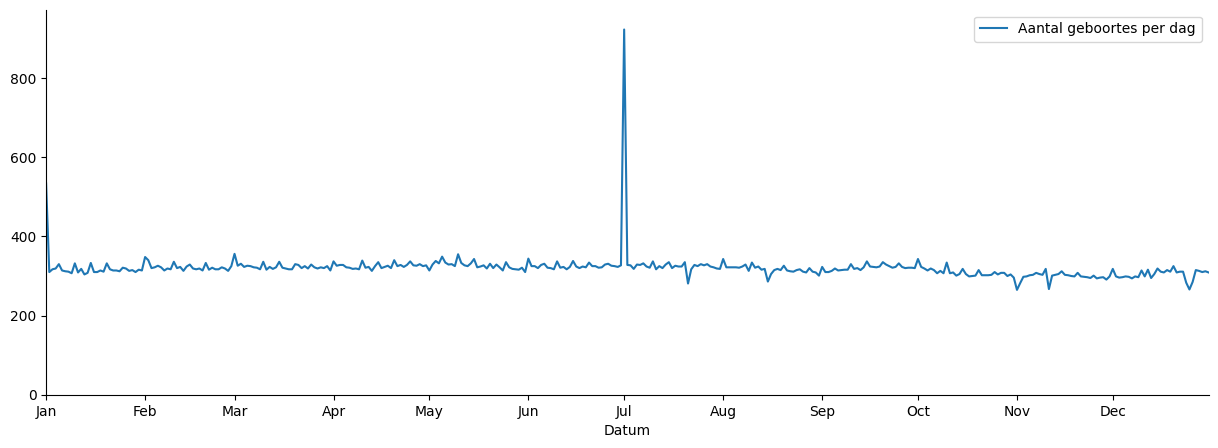

In [12]:
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter

x = geboortes_per_dag["datum"]
y = geboortes_per_dag["aantal_geboortes"]

plt.figure(figsize=(15, 5))
plt.plot(x, y, label="Aantal geboortes per dag")
plt.legend()

plt.xlim(geboortes_per_dag.datum.min(), geboortes_per_dag.datum.max())
plt.ylim(0, geboortes_per_dag.aantal_geboortes.max() + 50)
plt.xlabel("Datum")
plt.gca().xaxis.set_major_formatter(DateFormatter('%b'))
plt.gca().spines[['right', 'top']].set_visible(False)
plt.show()


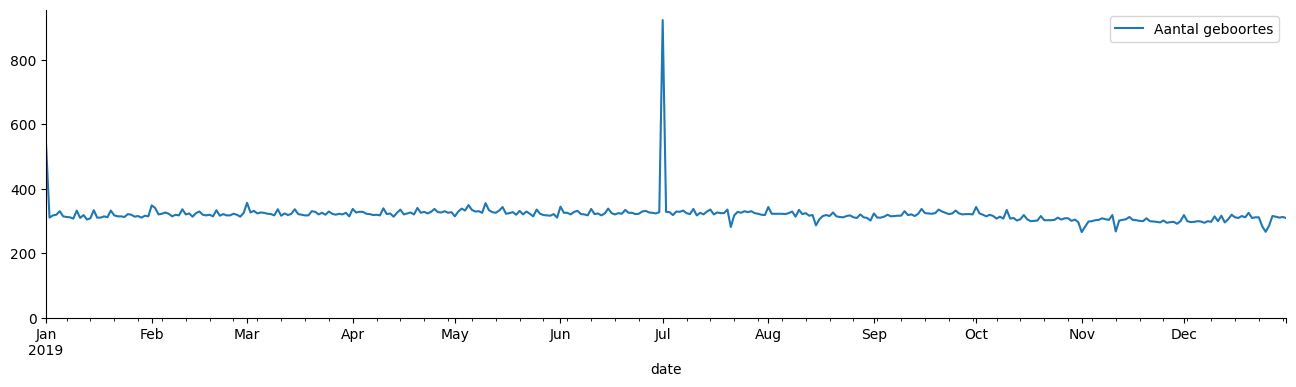

##

## Vraag 2: Outliers vinden & behandelen(1 punt)

We klassificeren een datum als een outlier als het aantal geboortes meer dan `50%` afwijkt van de gemiddelde waarde van de volledige dataset. Zoek alle outliers in de dataset. Druk de dagen van het jaar en het aantal geboortes af voor die outliers.

In [7]:
gem_geb = geboortes_per_dag.aantal_geboortes.mean()
low = gem_geb - gem_geb / 2
high = gem_geb + gem_geb / 2
outliers = geboortes_per_dag[(geboortes_per_dag.aantal_geboortes < low) | (geboortes_per_dag.aantal_geboortes > high)]

outliers 

,datum,dag_van_jaar,aantal_geboortes
0,2019-01-01,1,534
181,2019-07-01,182,923


,dag van het jaar,Aantal geboortes
0,1,534
181,182,923


## Van waar komen die outliers?
Ik zal je vertellen; de outliers op 1 januari en 1 juli komen doordat alle geboortes waarvoor de datum niet correct genoteerd is, de datum 1 januari (voor de eerste helft van het jaar) en op 1 juli (voor de tweede helft van het jaar) geplaatst worden. Om dit op te lossen, halen we in de grote geboortes DataFrame (met 1 lijn per geboorte) deze twee datums er volledig uit. Dus we gaan **alle** geboortes van 1 januari en 1 juli verwijderen uit deze dataframe en toevoegen aan de `df_wrong` dataframe met als reden `2019-01-01` en `2019-07-01`.

In [8]:
# zet rijen in df met de geboortedatum vanuit "outliers" in een tedelijke df_outliers
# en zorg ervoor dat die dezelfde kolommen heeft als df_wrong
df_outliers = df[df.datum.isin(outliers.datum)].rename(columns={'datum': 'reden'}).drop(columns='dag_van_jaar')
display(df_wrong.sample(5), df_outliers.sample(7))
display(df_wrong.shape, df_outliers.shape)

,gemeente,naam,geslacht,verwachte_datum,reden
14,Sint-Jans-Molenbeek,Andréa,Vrouwelijk,2019-03-13,2019-2-29
47,Bergen,Lysiane,Vrouwelijk,2019-03-12,2019-2-29
64,Eupen,Anneliese,Vrouwelijk,2019-02-24,2019-2-29
50,Olen,Jeannine,Vrouwelijk,2019-03-27,2019-2-29
71,Ciney,Alain,Mannelijk,2019-02-28,2019-2-29


,gemeente,naam,geslacht,verwachte_datum,reden
786,La Louvière,Dorian,Mannelijk,2019-06-30,2019-07-01
294,Seneffe,Thierry,Mannelijk,2019-01-07,2019-01-01
781,Kalmthout,Sten,Mannelijk,2019-07-05,2019-07-01
425,Oudergem,Jacques,Mannelijk,2019-07-24,2019-07-01
384,Anzegem,Nico,Mannelijk,2019-01-18,2019-01-01
825,Modave,Sylvie,Vrouwelijk,2019-07-09,2019-07-01
436,Ganshoren,Claudine,Vrouwelijk,2019-07-05,2019-07-01


(73, 5)

(1457, 5)

,gemeente,naam,geslacht,verwachte_datum,reden
54,Aartselaar,Martine,Vrouwelijk,2019-03-28,2019-2-29
13,Anderlecht,Dimitri,Mannelijk,2019-03-04,2019-2-29
22,Geldenaken,Julie,Vrouwelijk,2019-03-15,2019-2-29
41,Andenne,Pierre,Mannelijk,2019-03-01,2019-2-29
50,Olen,Jeannine,Vrouwelijk,2019-03-27,2019-2-29


,gemeente,naam,geslacht,verwachte_datum,reden
358,Luik,Richard,Mannelijk,2018-12-29,2019-01-01
392,Kapellen (Antwerpen),Lea,Vrouwelijk,2019-01-08,2019-01-01
507,Beerse,Patricia,Vrouwelijk,2019-01-07,2019-01-01
275,Asse,Wendy,Vrouwelijk,2019-07-05,2019-07-01
318,Zemst,Lucas,Mannelijk,2018-12-28,2019-01-01
254,Rochefort,Josée,Vrouwelijk,2019-07-07,2019-07-01
236,Ternat,Rita,Vrouwelijk,2019-02-25,2019-01-01


(73, 5)

(1457, 5)

In [9]:
# voeg de "outliers" rijen toe aan df_wrong

df_wrong = pd.concat([df_wrong, df_outliers], axis=0)
display(f"New {df_wrong.shape[0]=}")

'New df_wrong.shape[0]=1530'

In [10]:
# (voorzichtig) haal de rijen met de "outliers" uit df (laat enkel de doede in)
df = df[~df.datum.isin(outliers.datum)]

# check aantal rijen
print(f"{df.shape[0] + df_wrong.shape[0]=} (moet gelijk zijn aan {tot_records})")

df.shape[0] + df_wrong.shape[0]=116923 (moet gelijk zijn aan 116923)


## Vraag: hoeveel records zitten er nu in df_wrong (1punt)

In [11]:
df_wrong.shape[0]

1530

## Voeg op zicht een horizontale lijn toe(1 punt)
Maak dezelfde plot nu opnieuw met het aantal geboortes per dag. Voeg een horizontale lijn toe (op zicht) zodat de vijf laagste geboortecijfers eronder vallen.

In [ ]:
geb_counts1 = df.groupby(["dag_van_jaar"]).naam.count() # of .size() ipv naam
geboortes_per_dag1 = pd.DataFrame({"aantal_geboortes": geb_counts1}).reset_index()
geboortes_per_dag1.head()

,dag_van_jaar,aantal_geboortes
0,2,310
1,3,317
2,4,319
3,5,330
4,6,314


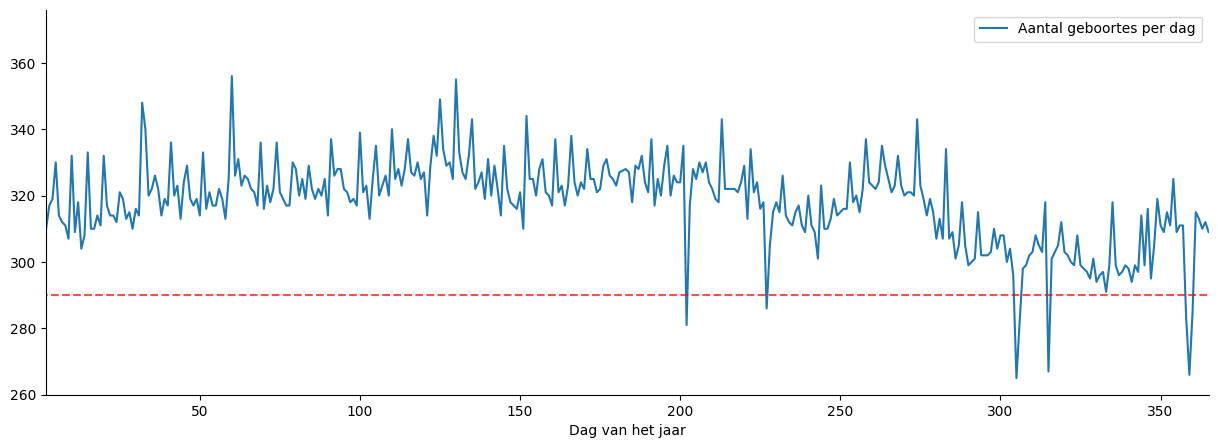

In [37]:
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter

x = geboortes_per_dag1["dag_van_jaar"]
y = geboortes_per_dag1["aantal_geboortes"]

y_cut = 290

plt.figure(figsize=(15, 5))
plt.plot(x, y, label="Aantal geboortes per dag")
plt.legend()

plt.xlim(geboortes_per_dag1.dag_van_jaar.min(), geboortes_per_dag1.dag_van_jaar.max())
plt.ylim(260, geboortes_per_dag1.aantal_geboortes.max() + 20)
plt.xlabel("Dag van het jaar")
plt.gca().spines[['right', 'top']].set_visible(False)
plt.hlines(y_cut, xmin=0, xmax=370, colors='red', linestyles='--', alpha=0.7)
plt.show()


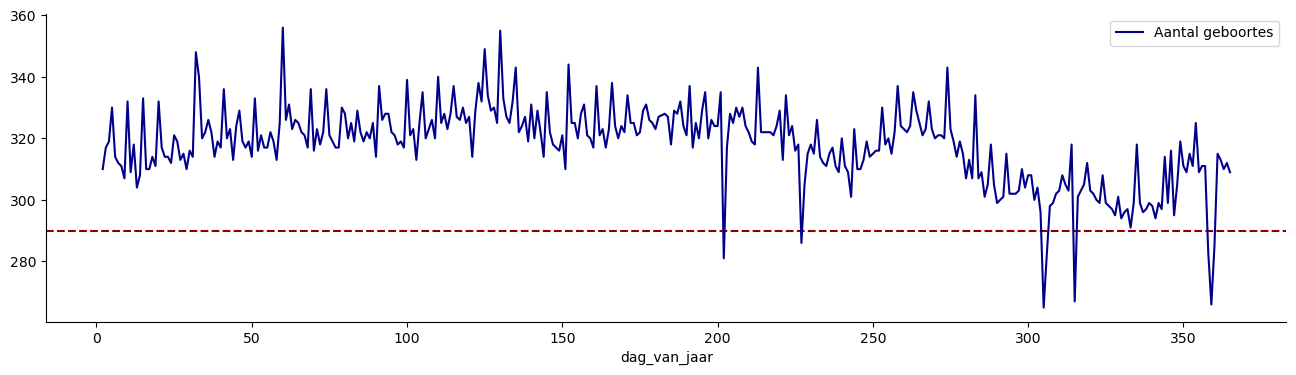

## Outliers (1 punt)
Dankzij de horizontale lijn die je getrokken hebt, ken je nu de grenswaarde voor de 5 extreme uitschieters in de 2de helft van het jaar. Schrijf code om die 5 extreme uitschieters te tonen (in totaal 8 datums)
 We zien dat er nog steeds redelijk wat uitschieters zijn, kan je code schrijven om de 5 extreme uitschieters in de 2e helft van het jaar identificeren (in totaal 8 datums)?

In [38]:
outliers1 = geboortes_per_dag1[(geboortes_per_dag1.aantal_geboortes < y_cut)]
outliers1 

,dag_van_jaar,aantal_geboortes
199,202,281
224,227,286
302,305,265
303,306,282
312,315,267
355,358,283
356,359,266
357,360,285


,dag van het jaar,Aantal geboortes
199,202,281
224,227,286
302,305,265
303,306,282
312,315,267
355,358,283
356,359,266
357,360,285


## Vraag: maak een boxplot(2 punten)
Maak een boxplot van de geboortes per dag

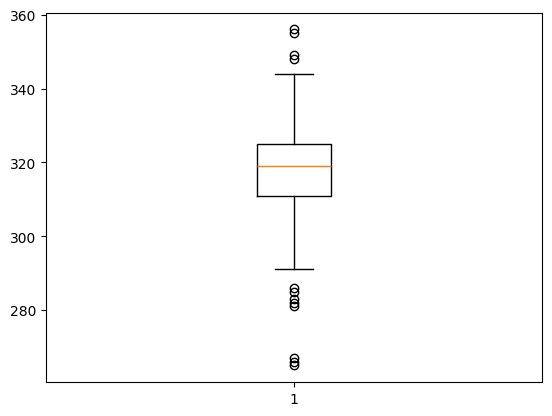

In [39]:
plt.boxplot(geboortes_per_dag1.aantal_geboortes)
plt.show()

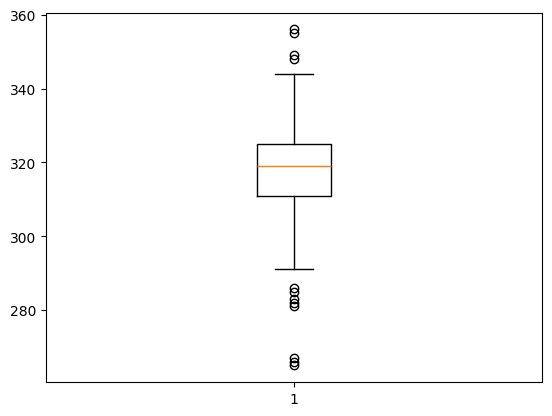

## Stap 3: Onderzoeksvragen
Onderzoek 1: Unisex namen
#### Een aantal statistieken(2 punten)
Sommige namen zijn unisex, dat wil zeggen dat zij hetzelfde zijn voor mannen en vrouwen. Beantwoord volgende 3 vragen over unisex namen in onze dataset:
 - Hoeveel unisex namen zijn er?
 - Wat is de meest voorkomende unisex naam; hiervoor zoek ik 3 namen (en getallen):
    - De meest populaire unisex naam bij mannen.
    - De meest populaire unisex naam bij vrouwen.
    - De meest popuaire unisex naam.

In [40]:
# het zal misschien efficienter zijn om een kleinere set df_namen met enkel de nodige info te de maken
df_namen = df.loc[:, ["naam", "geslacht"]]
df_namen["geslacht"] = df_namen["geslacht"].astype("category")
display(df_namen.describe(include="all"))

,naam,geslacht
count,115393,115393
unique,5237,2
top,Maria,Mannelijk
freq,1607,58202


In [41]:
geslachten = df_namen.geslacht.cat.categories
display(geslachten)
vrouwen_namen = df_namen[df_namen.geslacht == geslachten[1]]
mannen_namen = df_namen[df_namen.geslacht == geslachten[0]]
display(f"{vrouwen_namen.shape[0]=}, {mannen_namen.shape[0]=}")

Index(['Mannelijk', 'Vrouwelijk'], dtype='str')

'vrouwen_namen.shape[0]=57191, mannen_namen.shape[0]=58202'

In [ ]:
# unisex_namen df als inner join op naam die bij beide geslachten voorkomt
unisex_namen = pd.merge(vrouwen_namen.naam, mannen_namen.naam, how="inner")
# teacher's solution w/o two separate df's (names with only girls or only boys get NaN and get dropped):
# unisex_namen = df.groupby(['naam', 'geslacht']).size().unstack().dropna()
# unisex_namen heeft columns naam, mannelijk, vrouwelijk
# de 2 laatste met count per naam bij mannen en vrouwen respectievelijk - veel efficienter oplossing
print(f"Er zijn in totaal {unisex_namen.naam.nunique()} unisex namen.")

Er zijn in totaal 75 unisex namen.


In [ ]:
# hier zijn we enkel in namen zelf geinteresseerd
unamen = unisex_namen.naam.unique().tolist()

top_meisjes = vrouwen_namen[vrouwen_namen.naam.isin(unamen)].naam.value_counts().head(1)
# in the teacher's solution:
# top_jongens = unisex_namen.sort_values('Mannelijk', ascending=False).index[0]
top_jongens = mannen_namen[mannen_namen.naam.isin(unamen)].naam.value_counts().head(1)
top_beide = unisex_namen.naam.value_counts().head(1)

print(f"Populairse unisex naam bij de mannen: {top_jongens.index[0]}")
print(f"Populairse unisex naam bij de vrouwen: {top_meisjes.index[0]}")
print(f"Populairse unisex naam in het algemeen: {top_beide.index[0]}")

Populairse unisex naam bij de mannen: Maxime
Populairse unisex naam bij de vrouwen: Dominique
Populairse unisex naam in het algemeen: Dominique


Populairse unisex naam bij de mannen: Maxime
Populairse unisex naam bij de vrouwen: Dominique
Populairse unisex naam in het algemeen: Dominique


## Echte unisex namen (2 punt)
We zien dat er een vrij groot aantal namen veel meer voorkomen bij mannen dan vrouwen (en omgekeerd). Dit vinden we eigenlijk geen "echte" unisex namen. We noemen een naam "echt unisex" als de naam niet meer dan 50% meer voorkomt bij 1 van de 2 geslachten. Dus als er `x` mannen en `y` vrouwen zijn genaamd Chris, dan noemen we Chris "echt unisex" als `x <= 1.5 * y` en `y <= x * 1.5`. Filter je unisex dataframe tot een `df_real_unisex` waarbij je enkel de "echte" unisex namen weerhoudt.
- Beantwoord nu bovenstaande 3 vragen opnieuw voor deze dataset. Hierbij werk je best met een functie zodat je geen code moet herhalen!
- Zijn de echte unisex namen populairder bij mannen of vrouwen, of is de populariteit hetzelfde? Deze vraag kan je beantwoorden door te kijken naar het percentage mannen/vrouwen met een echte unisex naam.

In [44]:
real_unamen = []

for naam in unamen:
    naam_ser = df_namen[(df_namen.naam == naam)].value_counts().unstack()
    x, y = naam_ser.Mannelijk.iat[0], naam_ser.Vrouwelijk.iat[0]
    if (x <= 1.5 * y) and (y <= x * 1.5):
         real_unamen.append(naam)

print(f"{len(real_unamen)=}, {len(unamen)=}")

len(real_unamen)=15, len(unamen)=75


In [45]:
# real_unisex_namen door df_namen op de real_uni_namen te filteren, incl. geslacht
real_unisex_namen = df_namen[df_namen.naam.isin(real_unamen)]
print(f"Er zijn dus {real_unisex_namen.naam.nunique()} echt unisex namen.")

Er zijn dus 15 echt unisex namen.


In [46]:
real_top_meisjes = vrouwen_namen[vrouwen_namen.naam.isin(real_unamen)].naam.value_counts().head(1)
real_top_jongens = mannen_namen[mannen_namen.naam.isin(real_unamen)].naam.value_counts().head(1)
real_top_beide = real_unisex_namen.naam.value_counts().head(1)

print(f"Populairse echte unisex naam bij de mannen: {real_top_jongens.index[0]}")
print(f"Populairse echte unisex naam bij de vrouwen: {real_top_meisjes.index[0]}")
print(f"Populairse echte unisex naam in het algemeen: {real_top_beide.index[0]}")

Populairse echte unisex naam bij de mannen: Dominique
Populairse echte unisex naam bij de vrouwen: Dominique
Populairse echte unisex naam in het algemeen: Dominique


Populairse echte unisex naam bij de mannen: Dominique
Populairse echte unisex naam bij de vrouwen: Dominique
Populairse echte unisex naam in het algemeen: Dominique


## Percentage mannen en vrouwen met een echte unisex naam(1 punt)
Toon het percentage van de mannen en het percentage van de vrouwen die een echte unisex naam hebben

In [48]:
percentage_mannen = mannen_namen[mannen_namen.naam.isin(real_unamen)].shape[0] / mannen_namen.shape[0] * 100
percentage_vrouwen = vrouwen_namen[vrouwen_namen.naam.isin(real_unamen)].shape[0] / vrouwen_namen.shape[0] * 100

print(f"Percentage mannen met (echte) unisex naam: {percentage_mannen:.1f}%")
print(f"Percentage vrouwen met (echte) unisex naam: {percentage_vrouwen:.1f}%")

Percentage mannen met (echte) unisex naam: 0.4%
Percentage vrouwen met (echte) unisex naam: 0.5%


Percentage mannen met unisex naam: 0.4%
Percentage vrouwen met unisex naam: 0.5%


#### Visualizatie(2 punten)

Maak een visualizatie die alle echte unisex namen toont en de relatieve voorkomens bij mannen en vrouwen.

In [49]:
# maak een dataframe met percentages per geslacht voor elke naam
aantallen_per_unaam = real_unisex_namen.groupby("naam")["geslacht"].value_counts()
totalen_per_unaam = real_unisex_namen.naam.value_counts()
percentages_per_unaam = aantallen_per_unaam / totalen_per_unaam * 100
percentages = percentages_per_unaam.unstack(level=1).sort_values("Mannelijk")
percentages

geslacht,Mannelijk,Vrouwelijk
naam,,
Senna,40.000000,60.000000
Niki,40.000000,60.000000
Dominique,41.131105,58.868895
Joni,42.857143,57.142857
Yan,50.000000,50.000000
Vivian,50.000000,50.000000
Dursun,50.000000,50.000000
Beau,50.000000,50.000000
Yoni,50.000000,50.000000


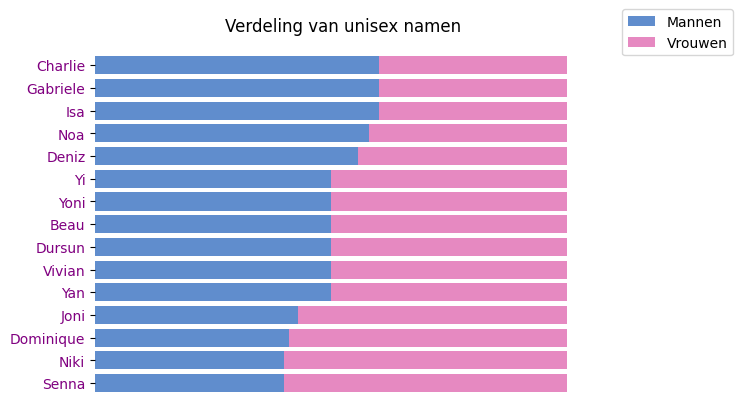

In [50]:
plt.barh(percentages.index, percentages["Mannelijk"], color="#608dcd", label="Mannen")
plt.barh(percentages.index, percentages["Vrouwelijk"], left=percentages.iloc[:, 0], color="#e689c1", label="Vrouwen")
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.title("Verdeling van unisex namen")
plt.xticks([])
plt.yticks(color="purple")
plt.gca().spines[['right', 'left', 'top', 'bottom']].set_visible(False)
plt.show()

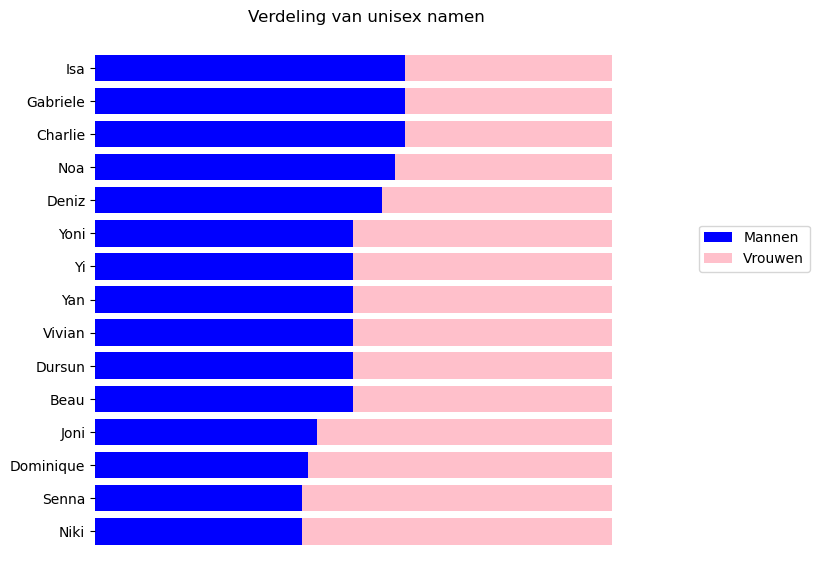

### Onderzoek 2: de accuraatheid van de geschatte bevallingsdatum
#### Evolutie vergelijken (1 punt)
In de volgende code zet ik de verwachte geboortedatum om naar een day_of_year.
Waarom zien de uiteindes van je plot er wat gek uit? Schrijf het antwoord neer in een strategisch geplaatste markdown cel (na de grafiek).

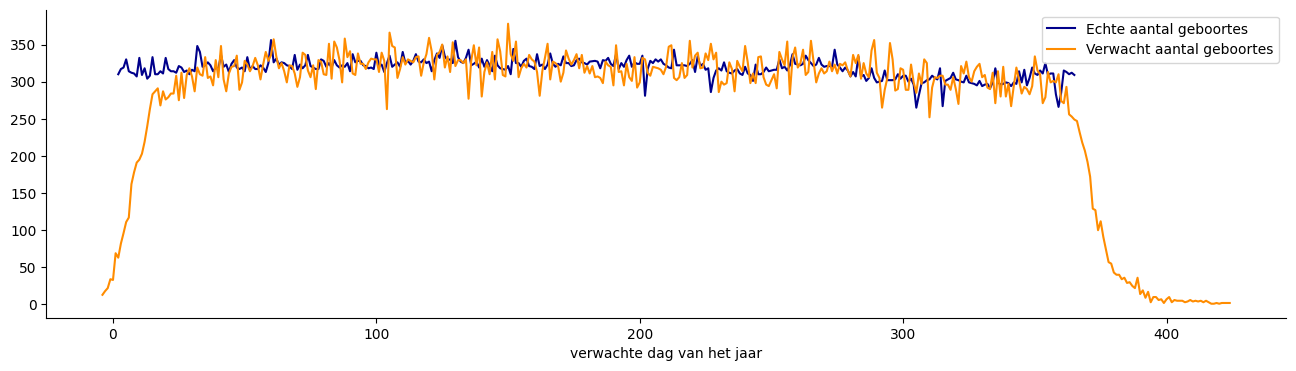

In [ ]:
# Zet de kolom 'verwachte datum' om naar een datetime object
# Voeg een kolom toe met de dag van het jaar
df['verwachte dag van het jaar'] = (df['verwachte_datum'] - df.datum.min()).dt.days + 2


# Maak nieuwe dataframes die groeperen per dag van ht jaar en per verwachte dag van het jaar
df_num_births_per_day = (df.groupby(['dag_van_jaar']).size()
                                                         .reset_index()
                                                         .rename(columns={0: 'Aantal geboortes'}))
df_num_births_expected_per_day = (df.groupby(['verwachte dag van het jaar']).size()
                                                                            .reset_index()
                                                                            .rename(columns={0: 'Aantal geboortes'}))
fig, ax = plt.subplots(figsize = (16, 4))
df_num_births_per_day.plot(x = 'dag_van_jaar',
                        y = 'Aantal geboortes',
                        ax = ax,
                        label = "Echte aantal geboortes",
                        color = 'darkblue')

df_num_births_expected_per_day.plot(x = 'verwachte dag van het jaar',
                                y = 'Aantal geboortes',
                                ax = ax,
                                label = "Verwacht aantal geboortes",
                                color = "darkorange")

ax.spines[['top', 'right']].set_visible(False)
#ax.set_ylim([150, 380])

## Vul hier in waarom de grafiek in het begin en het einde plots naar 0 gaat

De reden voor deze scherpe dalingen aan de kanten is dat de dataset is beperkt tot 1 jaar en bevat enkel de verwachte datums van geboortes die in 2019 plaats vonden. Iaw, we hebben volledige statistieken enkel voor de geboortes waar zowel verwachte datum als de werkelijke datum binnen de 2019 vallen, terwijl voor de verwachte datums in 2018 (linkere dal) zien we enkel babies die later zijn geboren en voor de verwachte datums in 2020 (rechtere dal) zitten er in deze dataset enkel babies die vroeger dan verwacht zijn geboren. Hoe verder de datum van 2019 ligt hoe minder die in onze dataset voorkomt.

Op zicht heeft dit effect niets met de convertie naar dagen van het jaar te maken, deze grafiek zou exact hetzelfde eruit zien als we de datums ipv dagen vh jaar op de x-ax laten staan. Nochtans, indien we enkel in een verschil tussen verwachte en werkelijke datums per jaar in het algemeen geinteresseerd zouden zijn, konden we de dayofyear functie gebruiken die met het cyclische karakter van dagen in een jaar rekening houdt. Dit zal de babies met verwachte datums van 2018 op het einde toevoegen en die van 2020 in het begin (omkeren dus), maar de grafieken zullen er gebalanceerder eruit zien.

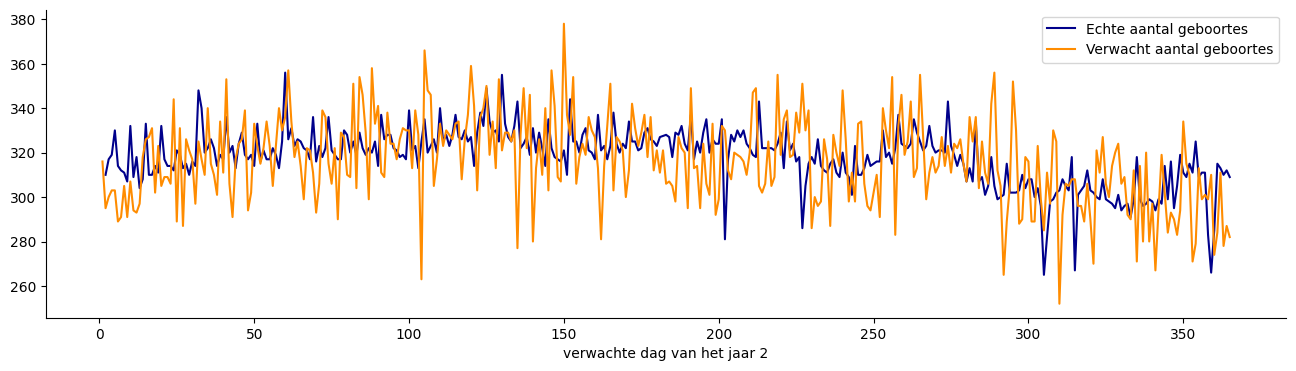

In [14]:
df['verwachte dag van het jaar 2'] = (df['verwachte_datum']).dt.dayofyear

df_num_births_per_day2 = (df.groupby(['dag_van_jaar']).size()
                                                        .reset_index()
                                                        .rename(columns={0: 'Aantal geboortes'}))
df_num_births_expected_per_day2 = (df.groupby(['verwachte dag van het jaar 2']).size()
                                                                            .reset_index()
                                                                            .rename(columns={0: 'Aantal geboortes'}))
fig, ax = plt.subplots(figsize = (16, 4))
df_num_births_per_day2.plot(x = 'dag_van_jaar',
                        y = 'Aantal geboortes',
                        ax = ax,
                        label = "Echte aantal geboortes",
                        color = 'darkblue')

df_num_births_expected_per_day2.plot(x = 'verwachte dag van het jaar 2',
                                y = 'Aantal geboortes',
                                ax = ax,
                                label = "Verwacht aantal geboortes",
                                color = "darkorange")

ax.spines[['top', 'right']].set_visible(False)

#### Verbanden bekijken(2 punten)
Maak een histogram van het aantal dagen dat babies te vroeg geboren werden in 2019. Toon alleen de babies die te vroeg geboren werden.

In [79]:
# Alle vervroegde geboortes in df_tevroeg met dagen te vroeg als een aparte kolom

df_tevroeg = df[df["datum"] < df["verwachte_datum"]]
df_tevroeg["dagen_te_vroeg"] = (df_tevroeg["datum"] - df_tevroeg["verwachte_datum"]).dt.days
df_tevroeg.info()


<class 'pandas.DataFrame'>
Index: 92340 entries, 2 to 314
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   gemeente                    92340 non-null  str           
 1   naam                        92340 non-null  str           
 2   geslacht                    92340 non-null  str           
 3   verwachte_datum             92340 non-null  datetime64[us]
 4   datum                       92340 non-null  datetime64[us]
 5   dag_van_jaar                92340 non-null  int32         
 6   verwachte dag van het jaar  92340 non-null  int64         
 7   dagen_te_vroeg              92340 non-null  int64         
dtypes: datetime64[us](2), int32(1), int64(2), str(3)
memory usage: 6.0 MB


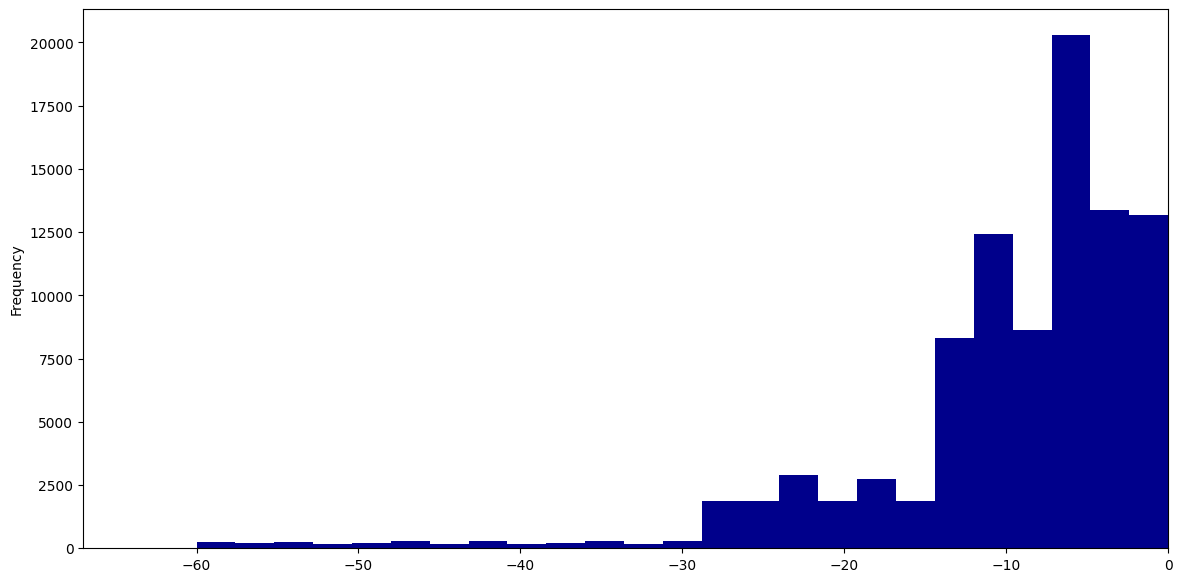

In [101]:
plt.figure(figsize=(14, 7))
plt.hist(df_tevroeg["dagen_te_vroeg"], range=(-60, 0), bins=25, color="darkblue")
plt.ylabel("Frequency")
plt.xlim(-67, 0)
plt.show()

Mijn grafiek verschilt lichtjes van uwe, ik vermoed omdat aantaal geboortes per dag een discreet getal is en de verdeling tussen de bins hangt er van de parameters zoals bins en range. Ik heb de exacte combinatie niet gevonden, maar hoop dat dit dicht genoeg is.

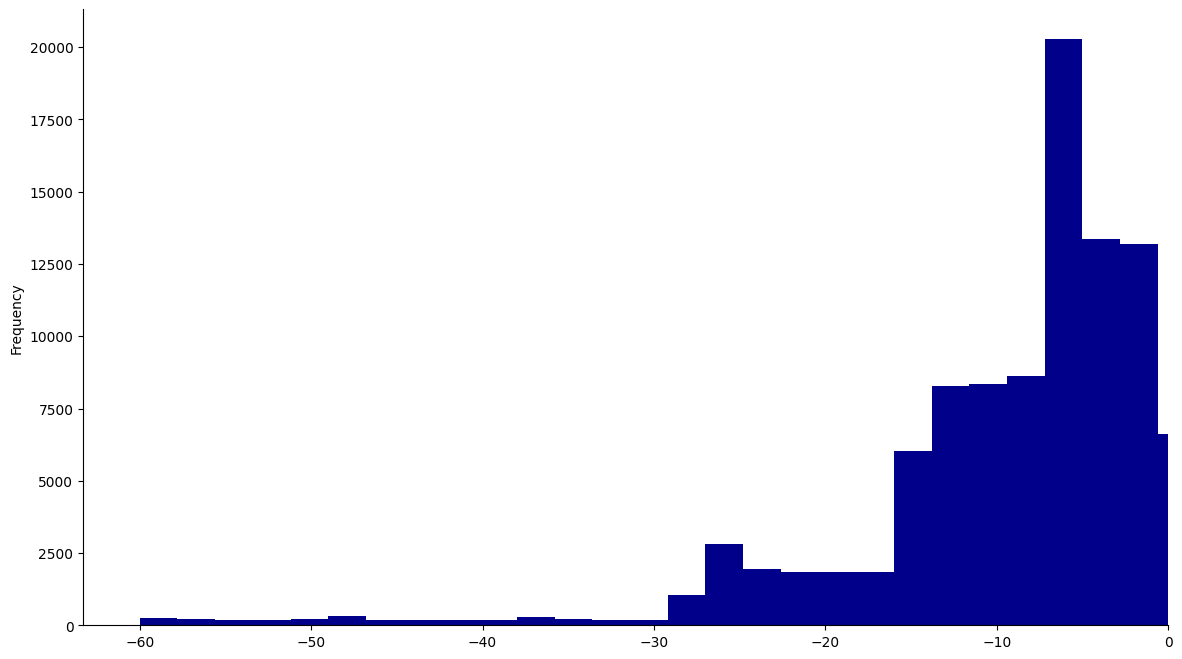